In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({'mathtext.default':  'regular' })
FontSize=13
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import sys

In [2]:
with open("../HPC_util_power/frontier_energy.txt", "r") as file:
    frontier= [float(line.strip()) for line in file if line.strip()]
with open("../HPC_util_power/fugaku_energy.txt", "r") as file:
    fugaku= [float(line.strip()) for line in file if line.strip()] 
with open("../HPC_util_power/marconi_util.txt", "r") as file:
    marconi = [float(line.strip()) for line in file if line.strip()]
with open("../HPC_util_power/polaris_util.txt", "r") as file:
    polaris= [float(line.strip()) for line in file if line.strip()]

In [3]:
with open("../EWF/marconi.txt", "r") as file:
    marconi_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/marconi.txt", "r") as file:
    marconi_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../EWF/fugaku.txt", "r") as file:
    fugaku_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/fugaku.txt", "r") as file:
    fugaku_wue= [float(line.strip()) for line in file if line.strip()]
    
with open("../EWF/polaris.txt", "r") as file:
    polaris_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/polaris.txt", "r") as file:
    polaris_wue= [float(line.strip()) for line in file if line.strip()]

with open("../EWF/frontier.txt", "r") as file:
    frontier_ewf= [float(line.strip()) for line in file if line.strip()]
with open("../WUE/frontier.txt", "r") as file:
    frontier_wue= [float(line.strip()) for line in file if line.strip()]
    

sys.path.append("..") 
from ThirstyFLOPS.operational import calculate_operational_water
marconi_config = {"wue": np.mean(marconi_wue), "wetbulb": None, "energy":1,"pue": 1.25, "energy_mix": None, "ewf": np.mean(marconi_ewf), "wsi_direct": 1, "wsi_indirect": 1}
    
    
wi_marconi  =[]
wi_fugaku  =[]
wi_polaris  =[]
wi_frontier  =[]
# Constants for each system
systems = {
    "marconi": {
        "wue": marconi_wue,
        "ewf": marconi_ewf,
        "pue": 1.25,
        "wsi_direct": 0.29,
        "wsi_indirect": 0.29,
        "output": wi_marconi
    },
    "fugaku": {
        "wue": fugaku_wue,
        "ewf": fugaku_ewf,
        "pue": 1.4,
        "wsi_direct": 0.36,
        "wsi_indirect": 0.36,
        "output": wi_fugaku
    },
    "polaris": {
        "wue": polaris_wue,
        "ewf": polaris_ewf,
        "pue": 1.65,
        "wsi_direct": 0.4237,
        "wsi_indirect": 0.39303875326672477,
        "output": wi_polaris
    },
    "frontier": {
        "wue": frontier_wue,
        "ewf": frontier_ewf,
        "pue": 1.05,
        "wsi_direct": 0.2716,
        "wsi_indirect": 0.2801834775358028,
        "output": wi_frontier
    }
}

# Assume all lists are the same length
n = len(fugaku_ewf)
for i in range(n):
    for name, cfg in systems.items():
        config = {
            "wue": cfg["wue"][i],
            "wetbulb": None,
            "energy": 1,
            "pue": cfg["pue"],
            "energy_mix": None,
            "ewf": cfg["ewf"][i],
            "wsi_direct": cfg["wsi_direct"],
            "wsi_indirect": cfg["wsi_indirect"]
        }
        _, _, _, wi = calculate_operational_water(config)
        cfg["output"].append(wi)

In [4]:


day_labels = []
for d in range(1, 366):
    day_labels += [d] * 24  
day_labels = np.array(day_labels)
df = pd.DataFrame({
    'day': day_labels,
    'Marconi': wi_marconi,
    'Fugaku': wi_fugaku,
    'Polaris': wi_polaris,
    'Frontier': wi_frontier
})

daily_avg = df.groupby('day').mean()

marconi_daily  = daily_avg['Marconi'].tolist()
fugaku_daily   = daily_avg['Fugaku'].tolist()
polaris_daily  = daily_avg['Polaris'].tolist()
frontier_daily = daily_avg['Frontier'].tolist()

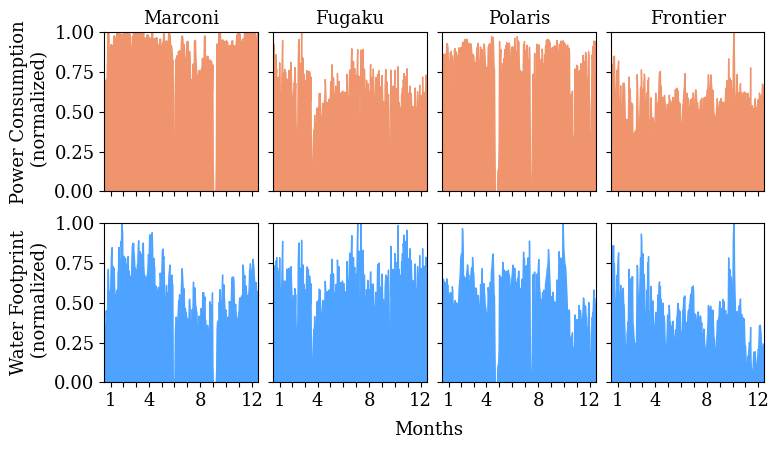

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=4, gridspec_kw={'hspace': 0.2, 'wspace': 0.1, 'bottom': 0.2, 
                    'top': 0.7, 'right':0.995, 'left':0.17}, figsize=(8,7),sharex=True, sharey=True)
#normalize fugaku
min_fugaku = min(fugaku)
max_fugaku = max(fugaku)
fugaku_norm = [(x - min_fugaku) / (max_fugaku - min_fugaku) for x in fugaku]
min_frontier = min(frontier)
max_frontier = max(frontier)
frontier_norm = [(x - min_frontier) / (max_frontier - min_frontier) for x in frontier]

#marcnoi 980
marconi_util = []
for i in range(len(marconi)):
   marconi_util.append(marconi[i]*24*980*(500+1200)/1000)
        
max_marconi_util = max(marconi_util)
min_marconi_util = min(marconi_util)
marconi_util_norm = [(x - min_marconi_util) / (max_marconi_util - min_marconi_util) for x in marconi_util]


yellow_patch = Patch(color='#EF946C', alpha=0.5, label='Power Consumption (norm.)',)
blue_patch = Patch(color='#4682B4', alpha=0.5, label='Water Footprint (norm.)',)
x_values= range(365)
axs[0][0].set_ylabel("Power Consumption\n (normalized)", fontsize=FontSize)
axs[1][0].set_ylabel("Water Footprint\n (normalized)", fontsize=FontSize)
axs[0][0].set_xlim(0, 364)
axs[0][0].set_ylim(0, 1)
axs[0][1].fill_between(x_values,fugaku_norm, color='#EF946C')
axs[0][0].set_title("Marconi", fontsize=FontSize)
axs[0][1].set_title("Fugaku", fontsize=FontSize)
axs[0][2].set_title("Polaris", fontsize=FontSize)
axs[0][3].set_title("Frontier", fontsize=FontSize)
axs[0][2].fill_between(x_values,polaris, color='#EF946C')
axs[0][3].fill_between(range(363),frontier_norm, color='#EF946C')

axs[0][0].fill_between(x_values, marconi_util_norm, color='#EF946C', linewidth=1.5)
axs[0][0].tick_params(axis='both', which='major', labelsize=FontSize)
axs[1][0].tick_params(axis='both', which='major', labelsize=FontSize)
axs[1][1].tick_params(axis='both', which='major', labelsize=FontSize)
axs[1][2].tick_params(axis='both', which='major', labelsize=FontSize)


fugaku_water=[]
for i in range(len(fugaku)):
    fugaku_water.append(fugaku[i]*wi_fugaku[i]*24/1000)

max_fugaku_water = max(fugaku_water)
min_fugaku_water = min(fugaku_water)
fugaku_water_norm = [(x - min_fugaku_water) / (max_fugaku_water - min_fugaku_water) for x in fugaku_water]
axs[1][1].fill_between(x_values,fugaku_water_norm, color='#4DA3FF')

polaris_tdp = 672 #kw
polaris_water=[]
for i in range(len(polaris)):
    polaris_water.append(polaris[i]*polaris_tdp*24*wi_polaris[i])

max_polaris_water = max(polaris_water)
min_polaris_water = min(polaris_water)
polaris_water_norm = [(x - min_polaris_water) / (max_polaris_water - min_polaris_water) for x in polaris_water]
axs[1][2].fill_between(x_values,polaris_water_norm, color='#4DA3FF')

marconi_water=[]
marconi_tdp = 24*980*(500+1200)/1000
for i in range(len(marconi)):
    marconi_water.append(marconi[i]*marconi_tdp*wi_marconi[i])
max_marconi_water = max(marconi_water)
min_marconi_water = min(marconi_water)
marconi_water_norm = [(x - min_marconi_water) / (max_marconi_water - min_marconi_water) for x in marconi_water]
axs[1][0].fill_between(x_values,marconi_water_norm, color='#4DA3FF')

frontier_water=[]

for i in range(len(frontier)):
    frontier_water.append(frontier[i]*wi_frontier[i]*1000*24)

max_frontier_water = max(frontier_water)
min_frontier_water = min(frontier_water)
frontier_water_norm = [(x - min_frontier_water) / (max_frontier_water - min_frontier_water) for x in frontier_water]
axs[1][3].fill_between(range(363),frontier_water_norm, color='#4DA3FF')

days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
midpoints = []
cumulative = 0
for days in days_in_month:
    midpoints.append(cumulative + days / 2)
    cumulative += days

month_labels = ["1", "", "", "4", "", "", 
                "", "8", "", "", "", "12"]

for ax in axs.flat:
    ax.set_xticks(midpoints)
    ax.set_xticklabels(month_labels, fontsize=FontSize)
axs[1][0].text(770, -0.3, "Months", fontsize=FontSize, ha='center', va='center')
plt.savefig("../figures/figure11.pdf", bbox_inches='tight')
